## ИИММ: практическая работа 2

Суть задания:
- Рассмотреть разноуровневые API PyTorch.
- Реализовать простую сеть для классификации рукописных цифр из датасета MNIST.
- Реализовать простую сеть для классификации рукописных цифр из датасета FashionMNIST.
- Решить головоломку с тремя фильтрами свёртки.

In [48]:
# do not change the code in the block below
# __________start of block__________
import json
import os
import re

import numpy as np
import torch
import torch.optim as optim
import torchvision
from IPython.display import clear_output
from matplotlib import pyplot as plt
from torch import nn
from torch.nn import functional as F
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader, sampler
import torchvision.datasets as datasets

# __________end of block__________

### Классификация на датасете MNIST

In [2]:
USE_GPU = True

dtype = torch.float32

if USE_GPU and torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print(device)

cuda


In [3]:
class Flatten(nn.Module):
    def forward(self, x):
        return flatten(x)


def flatten(x):
    N = x.shape[0] # read in N, C, H, W
    return x.view(N, -1)

In [ ]:
def get_accuracy(model, loader):
    if loader.dataset.train:
        print('Checking accuracy on validation set')
    else:
        print('Checking accuracy on test set')
    num_correct = 0
    num_samples = 0
    model.eval()  # переведите модель в режим оценки
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device=device, dtype=dtype)  # перемещение данных на CPU/GPU
            y = y.to(device=device, dtype=torch.long)
            scores = model(x)
            _, preds = scores.max(1)
            num_correct += (preds == y).sum()
            num_samples += preds.size(0)
        acc = float(num_correct) / num_samples
    return acc

In [74]:
def train(model, optimizer, loader_train, loader_val, epochs=1, print_every=100):
    """
    Входы:
    - model: PyTorch Module, задающий модель для обучения.
    - optimizer: Объект Optimizer, который мы будем использовать для обучения модели.
    - loader_train: Dataloader данных для обучения
    - loader_val: Dataloader данных для оценки
    - epochs: (Необязательно) Целое число, задающее количество эпох для обучения
    - print_every: Количество итераций, через которое точность модели
      должна периодически выводиться

    Возвращает: Списки значений точности на валидации в конце каждой эпохи.

    """
    loss_fn = nn.CrossEntropyLoss()
    model = model.to(device=device)  # переместить параметры модели в CPU/GPU
    train_accs = []
    val_accs = []
    for e in range(epochs):
        print('-' * 128)
        for t, (x, y) in enumerate(loader_train):
            model.train()  # переведите модель в режим обучения
            x = x.to(device=device, dtype=dtype)  # перемещение данных на устройство CPU/GPU
            y = y.to(device=device, dtype=torch.long)

            scores = model(x)
            loss = loss_fn(scores, y)

            # Обнуляем все градиенты для переменных, которые оптимизатор
            # будет обновляться.
            optimizer.zero_grad()

            # Это обратный проход: вычисляем градиент потерь по
            # относительно каждого обучаемого параметра модели.
            loss.backward()

            # Фактически обновляем параметры модели, используя градиенты?
            # вычисленные при обратном проходе.
            optimizer.step()

            if t % print_every == 0:
                print('Iteration %d, loss = %.4f' % (t, loss.item()))
                print(f'Got acc={(100 * get_accuracy(model, loader_val)):.3f}')
                print()
        val_accs.append(get_accuracy(model, loader_val))
    return val_accs

In [7]:
batch_size = 32
mnist_train = datasets.MNIST('.', download = True, train = True, transform = T.ToTensor())
loader_train = DataLoader(mnist_train, batch_size=batch_size, sampler=sampler.SubsetRandomSampler(range(50000)))

mnist_val = datasets.MNIST('.', download = True, train = True, transform = T.ToTensor())
loader_val = DataLoader(mnist_val, batch_size=batch_size, sampler=sampler.SubsetRandomSampler(range(50000, 60000)))

mnist_test = datasets.MNIST('.', download = True, train = False, transform = T.ToTensor())
loader_test = DataLoader(mnist_test, batch_size=batch_size, sampler=sampler.SubsetRandomSampler(range(10000)))

In [43]:
hidden_layer_size = 15
learning_rate = 1e-3

model = nn.Sequential(
    Flatten(),
    nn.Linear(1 * 28 * 28, hidden_layer_size),
    nn.BatchNorm1d(hidden_layer_size),
    nn.ReLU(),
    nn.Linear(hidden_layer_size, hidden_layer_size),
    nn.BatchNorm1d(hidden_layer_size),
    nn.ReLU(),
    nn.Linear(hidden_layer_size, 10),
)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

train(model, optimizer, loader_train, loader_val, epochs=5, print_every=500)

--------------------------------------------------------------------------------------------------------------------------------
Iteration 0, loss = 2.4235
Checking accuracy on validation set
Got 991 / 10000 correct (9.91)

Iteration 500, loss = 0.5068
Checking accuracy on validation set
Got 9080 / 10000 correct (90.80)

Iteration 1000, loss = 0.3366
Checking accuracy on validation set
Got 9248 / 10000 correct (92.48)

Iteration 1500, loss = 0.3393
Checking accuracy on validation set
Got 9382 / 10000 correct (93.82)

Checking accuracy on validation set
Got 9325 / 10000 correct (93.25)
--------------------------------------------------------------------------------------------------------------------------------
Iteration 0, loss = 0.3895
Checking accuracy on validation set
Got 9324 / 10000 correct (93.24)

Iteration 500, loss = 0.4027
Checking accuracy on validation set
Got 9395 / 10000 correct (93.95)

Iteration 1000, loss = 0.0558
Checking accuracy on validation set
Got 9481 / 10000 

[0.9325, 0.9469, 0.9543, 0.9537, 0.9546]

In [ ]:
print('Accuracy on the test:')
get_accuracy(loader_test, model)

Accuracy on the test:
Checking accuracy on test set
Got 9563 / 10000 correct (95.63)


0.9563

In [46]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)
count_parameters(model)

12235

### Классификация на датасете FashionMNIST

In [126]:
# do not change the code in the block below
# __________start of block__________
def get_predictions(model, eval_data, step=10):

    predicted_labels = []
    model.eval()
    with torch.no_grad():
        for idx in range(0, len(eval_data), step):
            y_predicted = model(eval_data[idx : idx + step].to(device))
            predicted_labels.append(y_predicted.argmax(dim=1).to(device))

    predicted_labels = torch.cat(predicted_labels)
    predicted_labels = ",".join([str(x.item()) for x in list(predicted_labels)])
    return predicted_labels


def get_accuracy(model, data_loader):
    predicted_labels = []
    real_labels = []
    model.eval()
    with torch.no_grad():
        for batch in data_loader:
            y_predicted = model(batch[0].to(device))
            predicted_labels.append(y_predicted.argmax(dim=1).to(device))
            real_labels.append(batch[1])

    predicted_labels = torch.cat(predicted_labels).to(device)
    real_labels = torch.cat(real_labels).to(device)
    accuracy_score = (predicted_labels == real_labels).type(torch.FloatTensor).mean()
    return accuracy_score


# __________end of block__________

In [122]:
# do not change the code in the block below
# __________start of block__________
assert os.path.exists(
    "hw_overfitting_data_dict.npy"
), "Please, download `hw_overfitting_data_dict.npy` and place it in the working directory"

# __________end of block__________

In [124]:
CUDA_DEVICE_ID = 0  # change if needed

# do not change the code in the block below
# __________start of block__________
device = (
    torch.device(f"cuda:{CUDA_DEVICE_ID}") if torch.cuda.is_available() else torch.device("cpu")
)
device
# __________end of block__________

device(type='cuda', index=0)

Text(0.5, 1.0, 'Image label: 0')

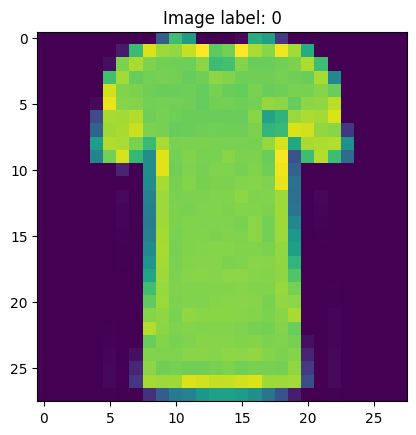

In [117]:
# do not change the code in the block below
# __________start of block__________

train_fmnist_data = datasets.FashionMNIST(
    ".", train=True, transform=torchvision.transforms.ToTensor(), download=True
)
test_fmnist_data = datasets.FashionMNIST(
    ".", train=False, transform=torchvision.transforms.ToTensor(), download=True
)


train_data_loader = torch.utils.data.DataLoader(
    train_fmnist_data, batch_size=32, shuffle=True, num_workers=10
)

test_data_loader = torch.utils.data.DataLoader(
    test_fmnist_data, batch_size=32, shuffle=False, num_workers=10
)

random_batch = next(iter(train_data_loader))
_image, _label = random_batch[0][0], random_batch[1][0]
plt.figure()
plt.imshow(_image.reshape(28, 28))
plt.title(f"Image label: {_label}")
# __________end of block__________

In [133]:
hidden_layer_size = 128
learning_rate = 1e-4

model_task_1 = nn.Sequential(
    Flatten(),
    nn.Linear(1 * 28 * 28, hidden_layer_size),
    nn.BatchNorm1d(hidden_layer_size),
    nn.ReLU(),
    nn.Linear(hidden_layer_size, hidden_layer_size),
    nn.BatchNorm1d(hidden_layer_size),
    nn.ReLU(),
    nn.Linear(hidden_layer_size, 10),
)
optimizer = optim.Adam(model_task_1.parameters(), lr=learning_rate)

model_task_1.to(device)

train(model_task_1, optimizer, train_data_loader, test_data_loader, epochs=10, print_every=500)

--------------------------------------------------------------------------------------------------------------------------------
Iteration 0, loss = 2.2887
Got acc=9.070

Iteration 500, loss = 0.5041
Got acc=80.830

Iteration 1000, loss = 0.4210
Got acc=82.680

Iteration 1500, loss = 0.2924
Got acc=84.200

--------------------------------------------------------------------------------------------------------------------------------
Iteration 0, loss = 0.4234
Got acc=85.230

Iteration 500, loss = 0.4750
Got acc=85.020

Iteration 1000, loss = 0.5473
Got acc=85.750

Iteration 1500, loss = 0.3761
Got acc=85.920

--------------------------------------------------------------------------------------------------------------------------------
Iteration 0, loss = 0.3162
Got acc=86.220

Iteration 500, loss = 0.2153
Got acc=86.350

Iteration 1000, loss = 0.2896
Got acc=86.040

Iteration 1500, loss = 0.1984
Got acc=86.880

--------------------------------------------------------------------------

[tensor(0.8508),
 tensor(0.8628),
 tensor(0.8703),
 tensor(0.8591),
 tensor(0.8801),
 tensor(0.8789),
 tensor(0.8874),
 tensor(0.8804),
 tensor(0.8856),
 tensor(0.8894)]

In [134]:
# do not change the code in the block below
# __________start of block__________
assert model_task_1 is not None, "Please, use `model_task_1` variable to store your model"

try:
    x = random_batch[0].to(device)
    y = random_batch[1].to(device)

    # compute outputs given inputs, both are variables
    y_predicted = model_task_1(x)
except Exception as e:
    print("Something is wrong with the model")
    raise e


assert y_predicted.shape[-1] == 10, "Model should predict 10 logits/probas"

print("Everything seems fine!")
# __________end of block__________

Everything seems fine!


In [135]:
train_acc_task_1 = get_accuracy(model_task_1, train_data_loader)
print(f"Neural network accuracy on train set: {train_acc_task_1:3.5}")

Neural network accuracy on train set: 0.93125


In [136]:
test_acc_task_1 = get_accuracy(model_task_1, test_data_loader)
print(f"Neural network accuracy on test set: {test_acc_task_1:3.5}")

Neural network accuracy on test set: 0.8894


In [137]:
assert test_acc_task_1 >= 0.885, "Train accuracy is below 0.885 threshold"
assert (
    train_acc_task_1 >= 0.905
), "Train accuracy is below 0.905 while test accuracy is fine. We recommend to check your model and data flow"

In [144]:
# do not change the code in the block below
# __________start of block__________
assert os.path.exists(
    "hw_fmnist_data_dict.npy"
), "Please, download `hw_fmnist_data_dict.npy` and place it in the working directory"

loaded_data_dict = np.load("hw_fmnist_data_dict.npy", allow_pickle=True)

submission_dict = {
    "train_predictions_task_1": get_predictions(
        model_task_1, torch.FloatTensor(loaded_data_dict.item()["train"])
    ),
    "test_predictions_task_1": get_predictions(
        model_task_1, torch.FloatTensor(loaded_data_dict.item()["test"])
    ),
}

with open("submission_dict_fmnist_task_1.json", "w") as iofile:
    json.dump(submission_dict, iofile)
print("File saved to `submission_dict_fmnist_task_1.json`")
# __________end of block__________

File saved to `submission_dict_fmnist_task_1.json`
